In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [98]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error

In [ ]:
df=pd.read_csv("/content/Housing.csv")

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
df.shape

(545, 13)

In [ ]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [ ]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'area'}>],
       [<Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'bathrooms'}>],
       [<Axes: title={'center': 'stories'}>,
        <Axes: title={'center': 'parking'}>]], dtype=object)

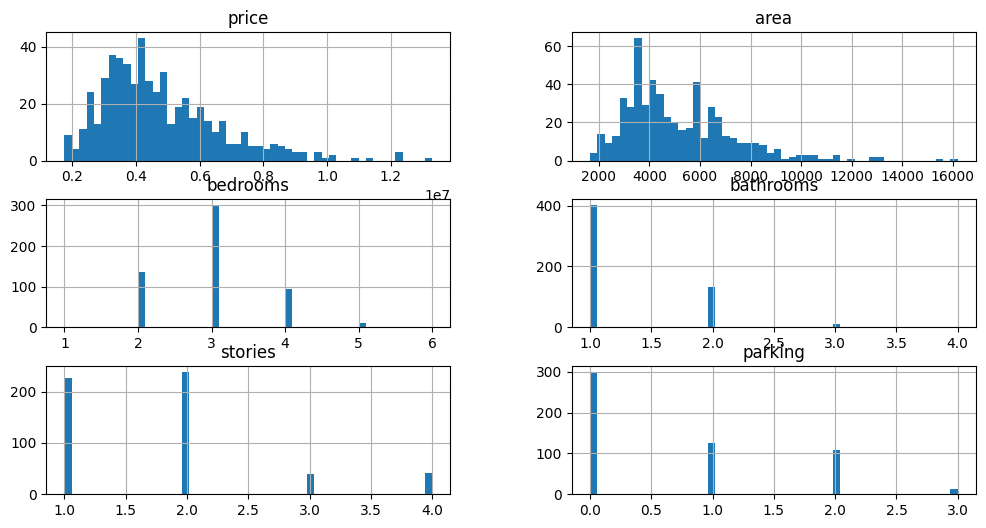

In [ ]:
df.hist(bins=50, figsize=(12,6))

<Axes: xlabel='price', ylabel='Count'>

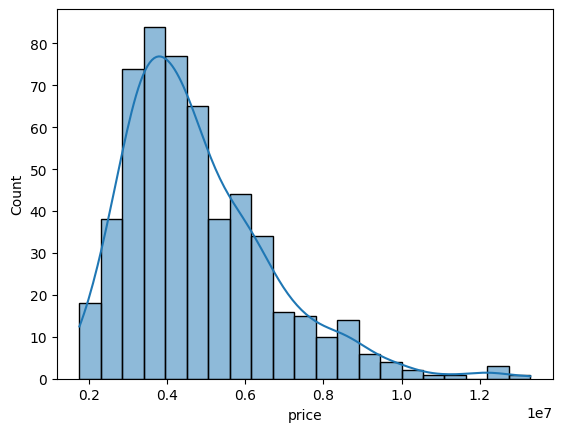

In [ ]:
sns.histplot(data=df,x='price',edgecolor='black',kde=True)

<Axes: xlabel='price'>

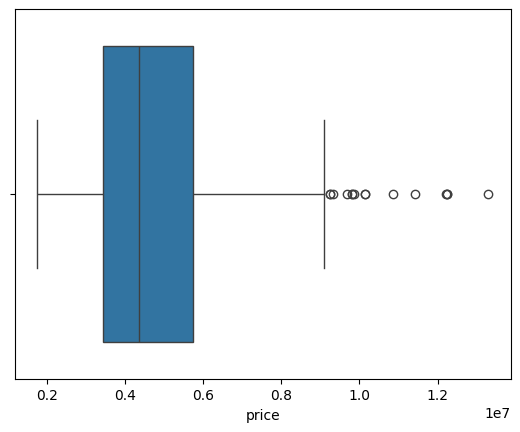

In [ ]:
sns.boxplot(data=df,x='price')

<Axes: xlabel='stories', ylabel='price'>

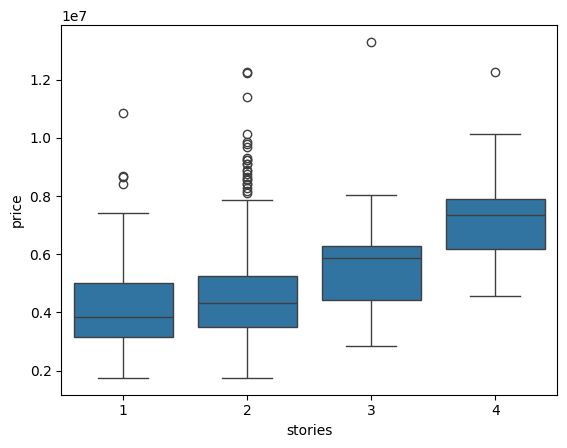

In [ ]:
sns.boxplot(data=df,x='stories',y='price')

In [ ]:
numcols=df.select_dtypes(include=['int64','float64'])
numcols

numcols.corr()

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


<Axes: >

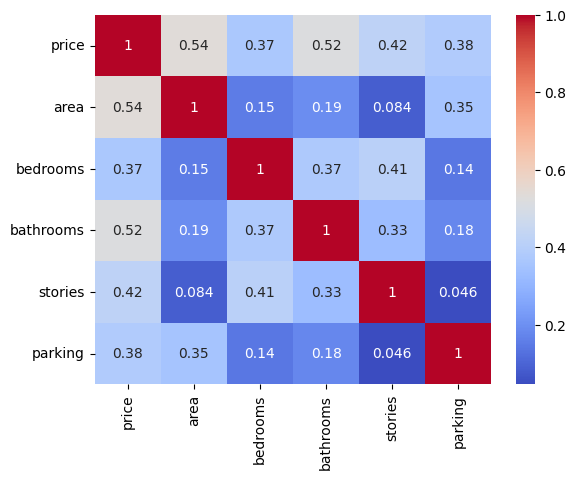

In [ ]:
sns.heatmap(
    numcols.corr(),
    annot=True,
    cmap='coolwarm'
)

# Preprocessing

<Axes: xlabel='price'>

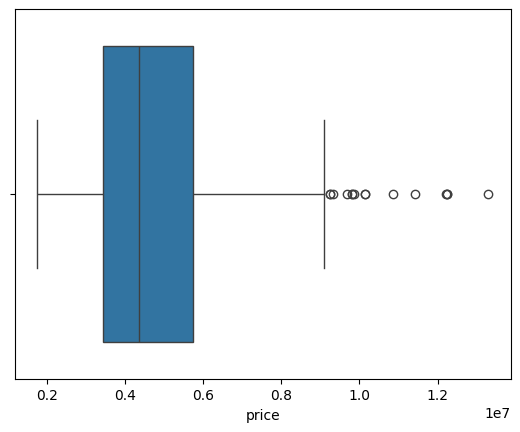

In [ ]:
sns.boxplot(data=df,x='price')

In [ ]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [ ]:
q1=df['price'].quantile(0.25)
q3=df['price'].quantile(0.75)

iqr=q3-q1

lb=q1-iqr*1.5
ub=q3+iqr*1.5

outliers = df[
    (df['price'] < lb) |
    (df['price'] > ub)
]

print("Number of outliers:", len(outliers))

Number of outliers: 15


In [ ]:
df['price']=df['price'].clip(lb,ub)

<Axes: xlabel='price'>

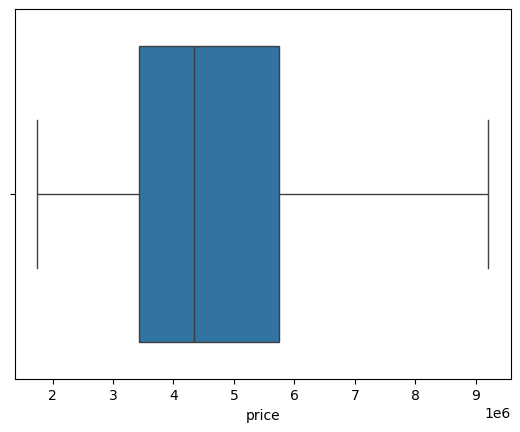

In [ ]:
sns.boxplot(data=df,x='price')

<Axes: xlabel='area'>

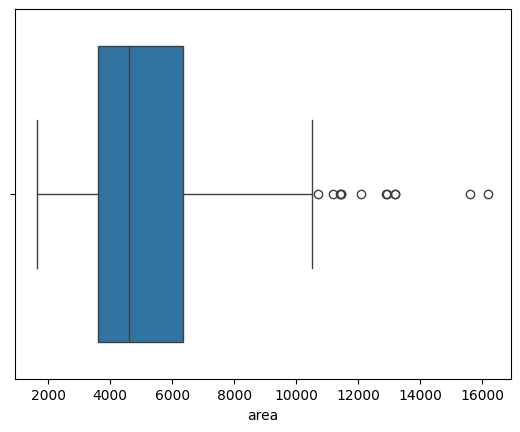

In [ ]:
sns.boxplot(data=df,x='area')

In [ ]:
q1=df['area'].quantile(0.25)
q3=df['area'].quantile(0.75)

iqr=q3-q1

lb=q1-iqr*1.5
ub=q3+iqr*1.5

outliers = df[
    (df['area'] < lb) |
    (df['area'] > ub)
]

print("Number of outliers:", len(outliers))

Number of outliers: 12


In [ ]:
df['area']=df['area'].clip(lb,ub)

<Axes: xlabel='area'>

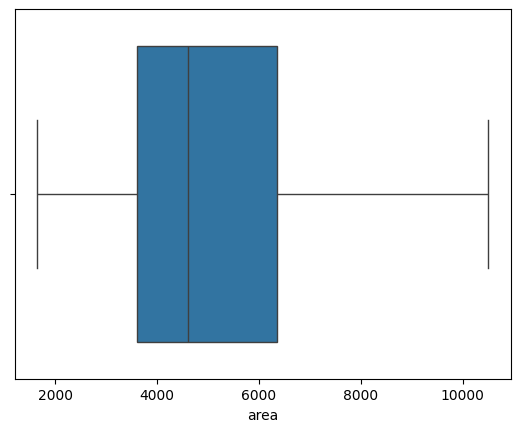

In [ ]:
sns.boxplot(data=df,x='area')

In [ ]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [ ]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,9205000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,9205000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,9205000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,9205000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,9205000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
numerical_features=['area','bedrooms','bathrooms','stories','parking']
binary_features=['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
categorical_features=['furnishingstatus']

In [81]:
numeric_transformer=Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='median')),
        ('scaler',StandardScaler())
    ]

)
numeric_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [82]:
categoric_transformer=Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('ohe',OneHotEncoder(handle_unknown='ignore', sparse_output=False,drop='first'))
    ]
)

categoric_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('ohe',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [83]:
binary_transformer=Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('ohe',OneHotEncoder(drop='if_binary'))
    ]
)

binary_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('ohe', OneHotEncoder(drop='if_binary'))])

In [85]:
preprocessor=ColumnTransformer(
    transformers=[
        ('numeric',numeric_transformer,numerical_features),
        ('cat',categoric_transformer,categorical_features),
        ('bin',binary_transformer,binary_features)
    ]
)
preprocessor

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['area', 'bedrooms', 'bathrooms', 'stories',
                                  'parking']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ohe',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['furnishingstatus']),
                                ('bin',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ohe',
                                                  OneHotEncoder(drop='if_binary'))]),
                                 ['mainroad', 'guestroom', 'basement',
                                  'hotwaterheating', 'airconditioning',
                                  'prefarea'])])

In [87]:
X=df.drop(['price'],axis=1)
y=df['price']

X

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [88]:
y

,price
0,9205000
1,9205000
2,9205000
3,9205000
4,9205000
...,...
540,1820000
541,1767150
542,1750000
543,1750000


In [91]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

X_train

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
46,6000,3,2,4,yes,no,no,no,yes,1,no,furnished
93,7200,3,2,1,yes,no,yes,no,yes,3,no,semi-furnished
335,3816,2,1,1,yes,no,yes,no,yes,2,no,furnished
412,2610,3,1,2,yes,no,yes,no,no,0,yes,unfurnished
471,3750,3,1,2,yes,no,no,no,no,0,no,unfurnished
...,...,...,...,...,...,...,...,...,...,...,...,...
71,6000,4,2,4,yes,no,no,no,yes,0,no,unfurnished
106,5450,4,2,1,yes,no,yes,no,yes,0,yes,semi-furnished
270,4500,3,2,3,yes,no,no,yes,no,1,no,furnished
435,4040,2,1,1,yes,no,no,no,no,0,no,unfurnished


In [92]:
y_test

,price
316,4060000
77,6650000
360,3710000
90,6440000
493,2800000
...,...
15,9100000
357,3773000
39,7910000
54,7350000


# using LR

In [93]:
lr_pipe=Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('model',LinearRegression())
    ]
)

lr_pipe.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['area', 'bedrooms',
                                                   'bathrooms', 'stories',
                                                   'parking']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['furnishingstatus']),
                                                 ('bin',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='if_binary'))]),
                                                  ['mainroad', 'guestroom',
                                                   'basement',
                                                   'hotwaterheating',
                                                   'airconditioning',
                                                   'prefarea'])])),
                ('model', LinearRegression())])

In [94]:
X_test

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
316,5900,4,2,2,no,no,yes,no,no,1,no,unfurnished
77,6500,3,2,3,yes,no,no,no,yes,0,yes,furnished
360,4040,2,1,1,yes,no,no,no,no,0,no,semi-furnished
90,5000,3,1,2,yes,no,no,no,yes,0,no,semi-furnished
493,3960,3,1,1,yes,no,no,no,no,0,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...
15,6000,4,1,2,yes,no,yes,no,no,2,no,semi-furnished
357,6930,4,1,2,no,no,no,no,no,1,no,furnished
39,6000,4,2,4,yes,no,no,no,yes,1,no,semi-furnished
54,6000,3,2,2,yes,yes,no,no,yes,1,no,semi-furnished


In [100]:
y_pred=lr_pipe.predict(X_test)

r2_lr=r2_score(y_test,y_pred)
rmse_lr=root_mean_squared_error(y_test,y_pred)
mae_lr=mean_absolute_error(y_test,y_pred)

print(f" --- Linear Regression Evaluation --- ")

print(f"R2 score = {round(r2_lr,4)}")
print(f"rmse  = {round(rmse_lr,4)}")
print(f"mae  = {round(mae_lr,4)}")

 --- Linear Regression Evaluation --- 
R2 score = 0.6802
rmse  = 1136696.5085
mae  = 881928.6138


# SGD

In [102]:
sgd_pipe=Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('model',SGDRegressor())
    ]
)

sgd_pipe.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['area', 'bedrooms',
                                                   'bathrooms', 'stories',
                                                   'parking']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['furnishingstatus']),
                                                 ('bin',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='if_binary'))]),
                                                  ['mainroad', 'guestroom',
                                                   'basement',
                                                   'hotwaterheating',
                                                   'airconditioning',
                                                   'prefarea'])])),
                ('model', SGDRegressor())])

In [103]:
y_pred=sgd_pipe.predict(X_test)

r2_sgd=r2_score(y_test,y_pred)
rmse_sgd=root_mean_squared_error(y_test,y_pred)
mae_sgd=mean_absolute_error(y_test,y_pred)

print(f" --- SGD Regression Evaluation --- ")

print(f"R2 score = {round(r2_sgd,4)}")
print(f"rmse  = {round(rmse_sgd,4)}")
print(f"mae  = {round(mae_sgd,4)}")

 --- SGD Regression Evaluation --- 
R2 score = 0.681
rmse  = 1135273.7058
mae  = 881700.4579


In [104]:
print(f"LinearRegression RMSE : {rmse_lr:.4f}")
print(f"SGDRegressor RMSE     : {rmse_sgd:.4f}")

if rmse_lr < rmse_sgd:
    print("LinearRegression wins")
else:
    print("SGDRegressor wins")

LinearRegression RMSE : 1136696.5085
SGDRegressor RMSE     : 1135273.7058
SGDRegressor wins


In [105]:
# ── Test Evaluation ───────────────────────────────────────────────
y_pred_test  = sgd_pipe.predict(X_test)

r2_test   = r2_score(y_test,  y_pred_test)
rmse_test = root_mean_squared_error(y_test, y_pred_test)
mae_test  = mean_absolute_error(y_test,  y_pred_test)

# ── Train Evaluation ──────────────────────────────────────────────
y_pred_train  = sgd_pipe.predict(X_train)

r2_train   = r2_score(y_train,  y_pred_train)
rmse_train = root_mean_squared_error(y_train, y_pred_train)
mae_train  = mean_absolute_error(y_train,  y_pred_train)

# ── Print Results ─────────────────────────────────────────────────
print("--- SGD Regression Evaluation ---")
print(f"{'Metric':10s}  {'Train':>10}  {'Test':>10}")
print("-" * 35)
print(f"{'R²':10s}  {round(r2_train,4):>10}  {round(r2_test,4):>10}")
print(f"{'RMSE':10s}  {round(rmse_train,4):>10}  {round(rmse_test,4):>10}")
print(f"{'MAE':10s}  {round(mae_train,4):>10}  {round(mae_test,4):>10}")

# ── Diagnose ──────────────────────────────────────────────────────
print()
gap = r2_train - r2_test
if gap > 0.1:
    print(f"Gap = {round(gap,4)} → ⚠️  Overfitting")
elif r2_test < 0.6:
    print(f"Gap = {round(gap,4)} → ⚠️  Underfitting")
else:
    print(f"Gap = {round(gap,4)} → ✅ Good Fit")

--- SGD Regression Evaluation ---
Metric           Train        Test
-----------------------------------
R²              0.6911       0.681
RMSE        926500.8739  1135273.7058
MAE         691703.154  881700.4579

Gap = 0.0101 → ✅ Good Fit
